In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib as plt
print("All done!")

All done!


In [3]:
url = "https://huggingface.co/datasets/HUBioDataLab/SELFormerMM/resolve/main/finetuning_datasets/classification/bbbp/bbbp.csv"
try:
    df = pd.read_csv(url)
    print("Downloaded!")
except:
    print("Download failed")

df = df[['smiles', 'p_np']].dropna().reset_index(drop=True)
print(f"Dataset size: {len(df)}")

Downloaded!
Dataset size: 2039


In [4]:
# seed drugs definition
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
def smiles_to_fp(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return gen.GetFingerprint(mol)
def smiles_to_array(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return gen.GetCountFingerprintAsNumPy(mol)

seed_smiles = {
    'Caffeine':    'Cn1cnc2c1c(=O)n(C)c(=O)n2C',
    'Diazepam':    'CN1C(=O)CN=C(c2ccccc2)c2cc(Cl)ccc21',
    'Nicotine':    'CN1CCCC1c1cccnc1',
    'Amphetamine': 'CC(N)Cc1ccccc1',
}

seed_fps = {}
for name, smi in seed_smiles.items():
    fp = smiles_to_fp(smi)
    if fp:
        seed_fps[name] = fp
        print(f"{name}: OK")
    else:
        print(f"{name}: Invalid SMILES")

Caffeine: OK
Diazepam: OK
Nicotine: OK
Amphetamine: OK


In [5]:
# Tanimoto similarity calculation
def tanimoto_to_seeds(smi):
    fp = smiles_to_fp(smi)
    if fp is None:
        return [0.0] * len(seed_fps)
    return [DataStructs.TanimotoSimilarity(fp, seed_fp)
           for seed_fp in seed_fps.values()]

print("Computing similarities...")
sim_matrix = df['smiles'].apply(tanimoto_to_seeds)
sim_df = pd.DataFrame(sim_matrix.tolist(), columns=list(seed_fps.keys()))
sim_df['max_similarity'] = sim_df.max(axis=1)
sim_df['mean_similarity'] = sim_df.mean(axis=1)
print(f"Done! shape: {sim_df.shape}")
print(sim_df.head())

Computing similarities...


[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not removing hydrogen atom without neighbors
[22:59:52] WARNING: not r

Done! shape: (2039, 6)
   Caffeine  Diazepam  Nicotine  Amphetamine  max_similarity  mean_similarity
0  0.070175  0.088235  0.100000     0.222222        0.222222         0.140571
1  0.067797  0.101449  0.096774     0.117647        0.117647         0.100263
2  0.117647  0.141026  0.109589     0.060606        0.141026         0.113979
3  0.096774  0.125000  0.158730     0.169811        0.169811         0.144025
4  0.092105  0.170732  0.128205     0.100000        0.170732         0.132355


[22:59:53] WARNING: not removing hydrogen atom without neighbors
[22:59:53] WARNING: not removing hydrogen atom without neighbors
[22:59:53] WARNING: not removing hydrogen atom without neighbors
[22:59:53] WARNING: not removing hydrogen atom without neighbors
[22:59:53] WARNING: not removing hydrogen atom without neighbors
[22:59:53] WARNING: not removing hydrogen atom without neighbors
[22:59:53] WARNING: not removing hydrogen atom without neighbors


In [8]:
# Train classifier
# fingerprint features
fp_features = np.stack(df['smiles'].apply(smiles_to_array).values)

# mixing fingerprint with similarity scores
X_combined = np.hstack([fp_features, sim_df.values])
y = df['p_np'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced'
)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)
auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC: {auc:.3f}")
print(classification_report(y_test, y_pred))

[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not removing hydrogen atom without neighbors
[23:02:47] WARNING: not r

ROC-AUC: 0.953
              precision    recall  f1-score   support

           0       0.92      0.68      0.78        96
           1       0.91      0.98      0.94       312

    accuracy                           0.91       408
   macro avg       0.91      0.83      0.86       408
weighted avg       0.91      0.91      0.90       408



In [10]:
# Ranking the candidates
df['repurposing_score'] = model.predict_proba(X_combined)[:, 1]
df['max_similarity'] = sim_df['max_similarity'].values

candidates = df[df['p_np'] == 0].sort_values(
    'repurposing_score', ascending=False
).head(15)

print("Top 15 Repurposing Candidates (currently labeled non-CNS):")
print(candidates[['smiles', 'repurposing_score', 'max_similarity']].to_string())

Top 15 Repurposing Candidates (currently labeled non-CNS):
                                                                                                                                        smiles  repurposing_score  max_similarity
275                                                                                                                            NNC(=O)c1ccncc1           0.910928        0.159091
256                                                                                                                        NC(N)=NCCN1CCCCCCC1           0.890000        0.106383
422                                                                                                            Nc1nc(N)c2nc(c3ccccc3)c(N)nc2n1           0.890000        0.175000
180                                                                                                          CCN(CC)CCOC(=O)C1(CCCCC1)C2CCCCC2           0.880000        0.083333
441                                                

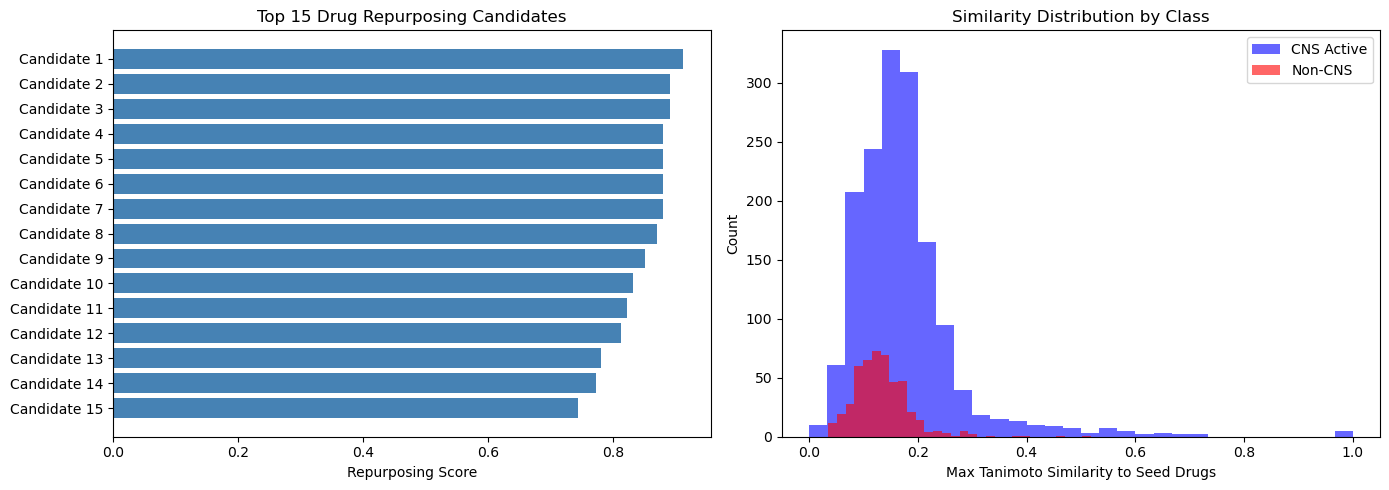

Saved!


In [12]:
# Visualization
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(15), candidates['repurposing_score'].values, color='steelblue')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels([f"Candidate {i+1}" for i in range(15)])
axes[0].set_xlabel('Repurposing Score')
axes[0].set_title('Top 15 Drug Repurposing Candidates')
axes[0].invert_yaxis()

axes[1].hist(df[df['p_np']==1]['max_similarity'], bins=30, 
             alpha=0.6, color='blue', label='CNS Active')
axes[1].hist(df[df['p_np']==0]['max_similarity'], bins=30, 
             alpha=0.6, color='red', label='Non-CNS')
axes[1].set_xlabel('Max Tanimoto Similarity to Seed Drugs')
axes[1].set_ylabel('Count')
axes[1].set_title('Similarity Distribution by Class')
axes[1].legend()

plt.tight_layout()
plt.savefig('repurposing_results.png', dpi=150)
plt.show()
print("Saved!")

In [13]:
# Summary

print("=" * 50)
print("   PROJECT C - DRUG REPURPOSING SUMMARY")
print("=" * 50)
print(f"Dataset:        BBBP ({len(df)} compounds)")
print(f"Seed drugs:     {', '.join(seed_fps.keys())}")
print(f"Features:       Tanimoto similarity to seeds")
print(f"Model:          Random Forest (100 trees)")
print(f"ROC-AUC:        {auc:.3f}")
print(f"Top candidates: {len(candidates)} non-CNS drugs ranked")
print("=" * 50)

   PROJECT C - DRUG REPURPOSING SUMMARY
Dataset:        BBBP (2039 compounds)
Seed drugs:     Caffeine, Diazepam, Nicotine, Amphetamine
Features:       Tanimoto similarity to seeds
Model:          Random Forest (100 trees)
ROC-AUC:        0.953
Top candidates: 15 non-CNS drugs ranked
